### Will a Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaraunt near where you are driving. Would you accept that coupon and take a short detour to the restaraunt? Would you accept the coupon but use it on a sunbsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaraunt? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \\$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\\$20 - \\$50). 

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece. 





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [63]:
data = pd.read_csv('data/coupons.csv')

In [64]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [45]:
data.sample(11)

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
5916,Work,Alone,Sunny,55,7AM,Coffee House,1d,Female,21,Married partner,...,1~3,1~3,4~8,4~8,1,1,0,0,1,1
7350,No Urgent Place,Alone,Sunny,55,6PM,Coffee House,2h,Male,26,Married partner,...,NaN,1~3,1~3,less1,1,0,0,0,1,1
12088,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Female,21,Unmarried partner,...,never,1~3,never,never,1,1,0,0,1,1
3885,Work,Alone,Sunny,80,7AM,Carry out & Take away,2h,Female,26,Married partner,...,1~3,1~3,4~8,less1,1,0,0,1,0,1
2496,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,1~3,less1,never,1,0,0,0,1,0
2368,No Urgent Place,Friend(s),Sunny,55,2PM,Coffee House,2h,Female,21,Single,...,less1,gt8,1~3,1~3,1,0,0,0,1,0
2598,Work,Alone,Sunny,55,7AM,Coffee House,2h,Male,50plus,Single,...,1~3,less1,1~3,less1,1,1,1,0,1,1
4833,No Urgent Place,Friend(s),Sunny,80,6PM,Restaurant(<20),1d,Female,21,Single,...,1~3,4~8,1~3,never,1,1,0,0,1,1
7769,Work,Alone,Rainy,55,7AM,Restaurant(<20),2h,Male,21,Unmarried partner,...,1~3,4~8,1~3,less1,1,1,1,0,1,0
7674,No Urgent Place,Alone,Sunny,80,10AM,Coffee House,1d,Male,36,Single,...,never,1~3,less1,less1,1,0,0,0,1,0


In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

2. Investigate the dataset for missing or problematic data.

<<Reveiw data for datatypes, columns with different datatypes, Values count in those columns, null value>>


In [54]:
# 2.1 Datatypes:-
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [62]:
# 2.2.1 columns with different datatypes : Object
data.select_dtypes("object").columns
# Index(['destination', 'passanger', 'weather', 'time', 'coupon', 'expiration',
#        'gender', 'age', 'maritalStatus', 'education', 'occupation', 'income',
#        'car', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20',
#        'Restaurant20To50'],
#       dtype='object')

data.select_dtypes("object")


,destination,passanger,weather,time,coupon,expiration,gender,age,maritalStatus,education,occupation,income,car,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50
1237,No Urgent Place,Alone,Sunny,2PM,Restaurant(<20),1d,Male,26,Single,Graduate degree (Masters or Doctorate),Sales & Related,$12500 - $24999,Scooter and motorcycle,less1,4~8,4~8,1~3,never
1238,No Urgent Place,Friend(s),Sunny,10AM,Coffee House,2h,Male,26,Single,Graduate degree (Masters or Doctorate),Sales & Related,$12500 - $24999,Scooter and motorcycle,less1,4~8,4~8,1~3,never
1239,No Urgent Place,Friend(s),Sunny,10AM,Bar,1d,Male,26,Single,Graduate degree (Masters or Doctorate),Sales & Related,$12500 - $24999,Scooter and motorcycle,less1,4~8,4~8,1~3,never
1240,No Urgent Place,Friend(s),Sunny,10AM,Carry out & Take away,2h,Male,26,Single,Graduate degree (Masters or Doctorate),Sales & Related,$12500 - $24999,Scooter and motorcycle,less1,4~8,4~8,1~3,never
1241,No Urgent Place,Friend(s),Sunny,2PM,Coffee House,1d,Male,26,Single,Graduate degree (Masters or Doctorate),Sales & Related,$12500 - $24999,Scooter and motorcycle,less1,4~8,4~8,1~3,never
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8293,Work,Alone,Rainy,7AM,Restaurant(<20),2h,Male,21,Single,Associates degree,Computer & Mathematical,$37500 - $49999,Car that is too old to install Onstar :D,never,less1,1~3,less1,less1
8294,Work,Alone,Rainy,7AM,Restaurant(20-50),1d,Male,21,Single,Associates degree,Computer & Mathematical,$37500 - $49999,Car that is too old to install Onstar :D,never,less1,1~3,less1,less1
8295,Work,Alone,Snowy,7AM,Restaurant(<20),2h,Male,21,Single,Associates degree,Computer & Mathematical,$37500 - $49999,Car that is too old to install Onstar :D,never,less1,1~3,less1,less1
8296,Work,Alone,Snowy,7AM,Restaurant(20-50),1d,Male,21,Single,Associates degree,Computer & Mathematical,$37500 - $49999,Car that is too old to install Onstar :D,never,less1,1~3,less1,less1


In [60]:
# 2.2.2 columns with different datatypes : Integer
data.select_dtypes("integer").columns
# Index(['temperature', 'has_children', 'toCoupon_GEQ5min', 'toCoupon_GEQ15min',
#        'toCoupon_GEQ25min', 'direction_same', 'direction_opp', 'Y'],
#       dtype='object')

data.select_dtypes("integer")

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,55,1,1,0,0,0,1,1
1,80,1,1,0,0,0,1,0
2,80,1,1,1,0,0,1,1
3,80,1,1,1,0,0,1,0
4,80,1,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...
12679,55,0,1,0,0,1,0,1
12680,55,0,1,0,0,0,1,1
12681,30,0,1,0,0,1,0,0
12682,30,0,1,1,1,0,1,0


In [68]:
# 2.3 unique values in object datatype columns


# data['destination'].value_counts()
# data['passanger'].value_counts()
# data['weather'].value_counts()
# data['time'].value_counts()
# data['coupon'].value_counts()
# data['Bar'].value_counts()
data['car'].value_counts()



Scooter and motorcycle                      22
Mazda5                                      22
do not drive                                22
crossover                                   21
Car that is too old to install Onstar :D    21
Name: car, dtype: int64

In [70]:
# 2.4 check for null values
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [79]:
### Result from data analysis steps:- 
# Car values:- out of 12684 total rows, 12576 rows have null value. unique values in column does not make any contirbution to the result. 
# My decision to drop this row from the dataframe
data_noCardata = data.drop(columns=['car'])

# REPLACE NULL :- Bar, CoffeeHouse, CarryAway, RestaurantLessThan20, Restaurant20To50 columns have valueable inofmrtaion
# replace null value to anything but not "0=NO & 1=YES" to avoid conflict with original datasets. In that case, replace null value with 1.1

data.fillna({'Bar': 1.1, 'CoffeeHouse': 1.1,'CarryAway': 1.1, 'RestaurantLessThan20': 1.1,'Restaurant20To50': 1.1 }, inplace=True)
data_noCardata.isnull().sum()

# OR DROP NULL :- based on data in above columns with null value, better to keep the rows rather than removing them completely
# data.dropna(inplace=True)
# data
# data.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

4. What proportion of the total observations chose to accept the coupon? 



In [86]:
# percentage of accepttance of coupon = total response that said -"yes" (valeue = 1)/total number of rows
total_rowcount = len(data)
total_yescount = data['Y'].sum()
total_rowcount, total_yescount

# percentage of acceptance 
percentageofAcceptdCoupon = (total_yescount/total_rowcount)*100
percentageofAcceptdCoupon

56.84326710816777

5. Use a bar plot to visualize the `coupon` column.

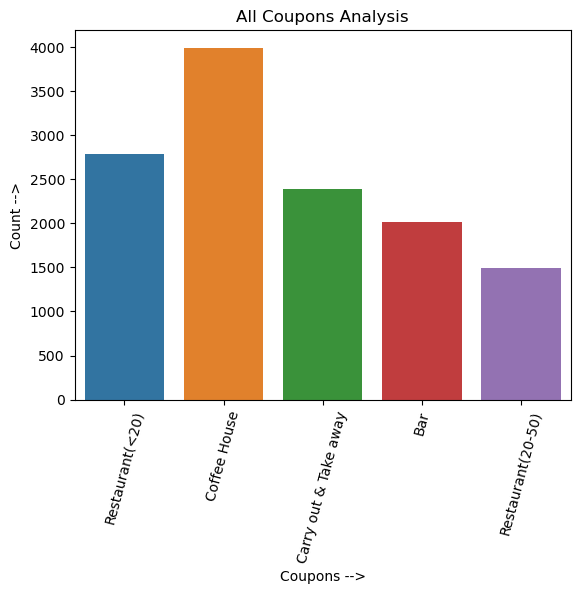

In [97]:
# check unique values in coupon column
# data['coupon'].value_counts()

# create plotly bar plot with all different coupons
# px.bar(data, x='coupon', title = 'Coupon Analysis', color = 'coupon')

# Bar plot with sns
sns.countplot(x='coupon', data=data)
plt.xlabel('Coupons -->')
plt.ylabel('Count -->')
plt.title('All Coupons Analysis')
plt.tick_params(axis='x', rotation=75)
plt.show()


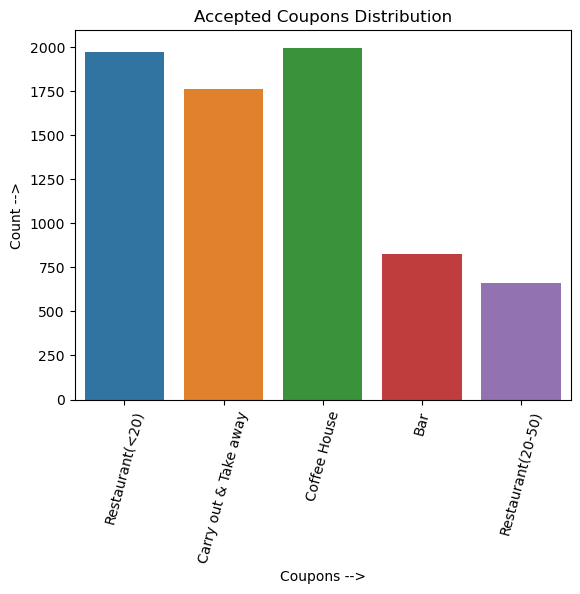

In [101]:
# 5.1 - Distribution of ACEEPTED Coupons 
sns.countplot(x='coupon', data=data[data['Y']==1])
plt.xlabel('Coupons -->')
plt.ylabel('Count -->')
plt.title('Accepted Coupons Distribution')
plt.tick_params(axis='x', rotation=75)
plt.show()

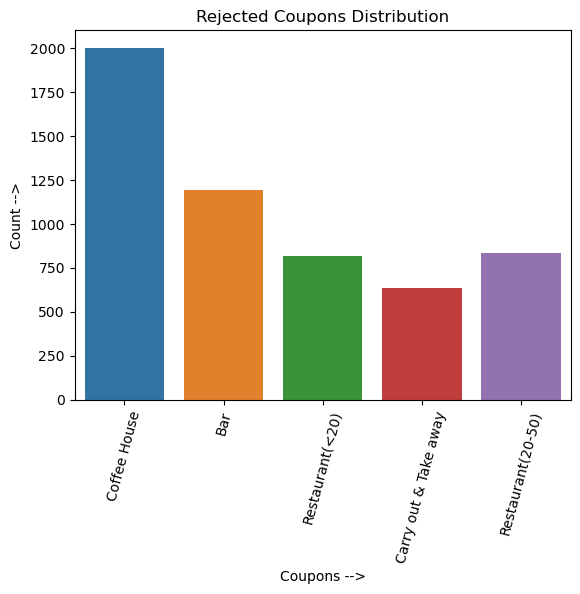

In [104]:
# 5.1 - Distribution of REJECTED Coupons 
sns.countplot(x='coupon', data=data[data['Y']==0])
plt.xlabel('Coupons -->')
plt.ylabel('Count -->')
plt.title('Rejected Coupons Distribution')
plt.tick_params(axis='x', rotation=75)
plt.show()

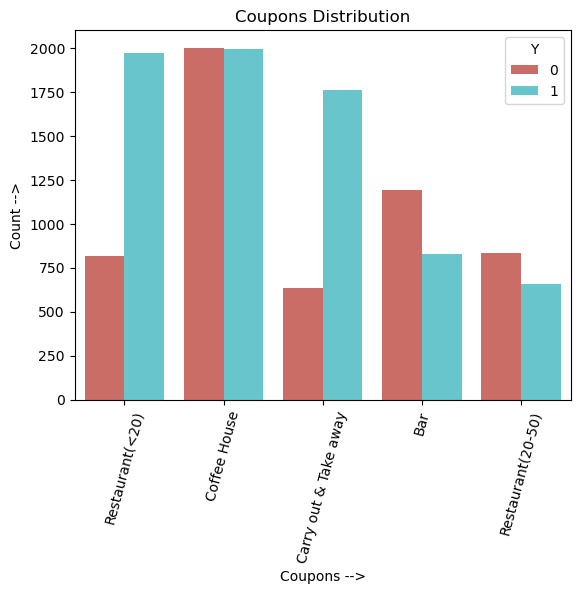

In [127]:
# Distribution of coupons 


sns.countplot(data=data, x='coupon', hue='Y', palette ='hls')

plt.xlabel('Coupons -->')
plt.ylabel('Count -->')
plt.title('Coupons Distribution')
plt.tick_params(axis='x', rotation=75)
plt.show()


6. Use a histogram to visualize the temperature column.

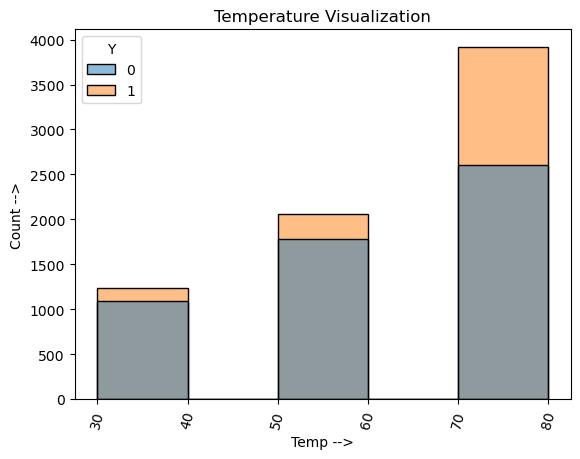

In [118]:
# data['temperature'].value_counts()

# Coupon Accetptance/ Rejection based on different temperature
sns.histplot(data=data, x='temperature', hue='Y', bins=5)
plt.xlabel('Temp -->')
plt.ylabel('Count -->')
plt.title('Temperature Visualization')
plt.tick_params(axis='x', rotation=75)
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [131]:
# Create new dataframe as "bar_coupons_data"
bar_coupons_data = data[data['coupon']=='Bar']
bar_coupons_data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,1.1,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,1.1,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,1.1,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


In [133]:
bar_coupons_data.shape
# 2017 rows with coupon as 'Bar' 

(2017, 26)

In [135]:
bar_coupons_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2017 entries, 9 to 12682
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           2017 non-null   object
 1   passanger             2017 non-null   object
 2   weather               2017 non-null   object
 3   temperature           2017 non-null   int64 
 4   time                  2017 non-null   object
 5   coupon                2017 non-null   object
 6   expiration            2017 non-null   object
 7   gender                2017 non-null   object
 8   age                   2017 non-null   object
 9   maritalStatus         2017 non-null   object
 10  has_children          2017 non-null   int64 
 11  education             2017 non-null   object
 12  occupation            2017 non-null   object
 13  income                2017 non-null   object
 14  car                   13 non-null     object
 15  Bar                   2017 non-null  

2. What proportion of bar coupons were accepted?


In [144]:
# Accpted bar coupon percentage = accepted bar coupons/total bar coupons*100

# percentage of accepted bar coupons
accepted_bar_coupons = (bar_coupons_data['Y'].sum()/len(bar_coupons_data))*100
accepted_bar_coupons

#accepted proportion of bar coupons = 41%

41.00148735746158

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [149]:
# Recall the values in Bar column from master dataframe
data['Bar'].value_counts()

# values in Bar column corresponding to the value where coupon type is 'Bar'
bar_coupons_data['Bar'].value_counts()

never    830
less1    570
1~3      397
4~8      150
gt8       49
1.1       21
Name: Bar, dtype: int64

In [161]:
# dataframe for those who went to bar 3 or fewer times:-
barvisit_3orless = bar_coupons_data.loc[bar_coupons_data['Bar'].isin(['never','less1','1~3'])]

# dataframe for those who went to bar 3 times or more:-
barvisit_4ormore = bar_coupons_data.loc[bar_coupons_data['Bar'].isin(['4~8','gt8','1.1'])]
# barvisit_4ormore

# Percentage of acceptance of bar coupon with who went to bar 3 or LESS times => ~37%
percentage_3orless = (barvisit_3orless['Y']==1).sum()/len(barvisit_3orless)*100
percentage_3orless

# Percentage of acceptance of bar coupon with who went to bar 3 or MORE times => ~76%
percentage_4ormore = (barvisit_4ormore['Y']==1).sum()/len(barvisit_4ormore)*100
percentage_4ormore

# Acceptance rate of bar coupon is twice as high with the frequent bar vistors who visits 3 or 
# more times (~76%) a month compare to bar vistors who visits 3 or less times in a month (~37%).

76.88442211055276

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [164]:
bar_coupons_data['Y'].value_counts()
bar_coupons_data['age'].unique()

array(['21', '46', '26', '31', '41', '50plus', '36', 'below21'],
      dtype=object)

In [165]:
#dataframe with vistors who go to a bar more than once a month and are over the age of 25
drivers_25andmore_onceormore = bar_coupons_data.loc[bar_coupons_data['age'].isin(['46','26','31','41','50plus','36']) &
                                                   bar_coupons_data['Bar'].isin(['1~3','4~8','gt8','1.1'])]

drivers_25andmore_onceormore



,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
112,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,26,Unmarried partner,...,gt8,4~8,1~3,less1,1,0,0,0,1,1
123,Home,Alone,Sunny,55,6PM,Bar,1d,Male,26,Unmarried partner,...,gt8,4~8,1~3,less1,1,0,0,1,0,1
127,Work,Alone,Sunny,55,7AM,Bar,1d,Male,26,Unmarried partner,...,gt8,4~8,1~3,less1,1,1,1,0,1,1
156,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,26,Single,...,gt8,gt8,gt8,gt8,1,0,0,0,1,1
167,Home,Alone,Sunny,55,6PM,Bar,1d,Male,26,Single,...,gt8,gt8,gt8,gt8,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12481,No Urgent Place,Friend(s),Sunny,80,10PM,Bar,1d,Female,26,Unmarried partner,...,never,4~8,4~8,less1,1,1,0,0,1,1
12482,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Female,26,Unmarried partner,...,never,4~8,4~8,less1,1,1,0,0,1,1
12485,No Urgent Place,Alone,Rainy,55,10AM,Bar,1d,Female,26,Unmarried partner,...,never,4~8,4~8,less1,1,1,0,0,1,1
12488,No Urgent Place,Partner,Rainy,55,6PM,Bar,2h,Female,26,Unmarried partner,...,never,4~8,4~8,less1,1,1,0,0,1,1


In [168]:
drivers_25andmore_onceormore['Bar'].unique()
# ['1~3', 'gt8', '4~8']
drivers_25andmore_onceormore['age'].unique() 
# ['26', '31', '50plus', '41', '36', '46']

array(['1~3', 'gt8', '4~8'], dtype=object)

In [171]:
frequent_accepted_visitor = drivers_25andmore_onceormore['Y'].sum()/len(drivers_25andmore_onceormore)*100
frequent_accepted_visitor

69.52380952380952

In [174]:
## other bar visitors
other_barvisitors = bar_coupons_data.loc[~bar_coupons_data.index.isin([drivers_25andmore_onceormore])]
other_barvisitors['Bar'].unique()

array(['never', 'less1', '1~3', 'gt8', 1.1, '4~8'], dtype=object)

In [175]:
# other bar vistitors acceptance (driver not less than 25 and visting once or less in a month)
other_accepted_visitors = other_barvisitors['Y'].sum()/len(other_barvisitors)*100
other_accepted_visitors

41.00148735746158

In [ ]:
#  Onbservation with drivers :- acceptance rate between drivers who go to a bar more than once a month and are over the age of 25
# is 69% whereas aceptance with other bar visitors is 41%

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry. 


In [178]:
#  check available values
bar_coupons_data['Bar'].unique()
# ['never', 'less1', '1~3', 'gt8', 1.1, '4~8']

bar_coupons_data['passanger'].unique()
# ['Kid(s)', 'Alone', 'Friend(s)', 'Partner']

bar_coupons_data['occupation'].unique()

array(['Unemployed', 'Architecture & Engineering', 'Student',
       'Education&Training&Library', 'Healthcare Support',
       'Healthcare Practitioners & Technical', 'Sales & Related',
       'Management', 'Arts Design Entertainment Sports & Media',
       'Computer & Mathematical', 'Life Physical Social Science',
       'Personal Care & Service', 'Community & Social Services',
       'Office & Administrative Support', 'Construction & Extraction',
       'Legal', 'Retired', 'Installation Maintenance & Repair',
       'Transportation & Material Moving', 'Business & Financial',
       'Protective Service', 'Food Preparation & Serving Related',
       'Production Occupations',
       'Building & Grounds Cleaning & Maintenance',
       'Farming Fishing & Forestry'], dtype=object)

In [183]:
drivers_once_notkid_occupation = bar_coupons_data.loc[~bar_coupons_data['passanger'].isin(['Kid(s)']) &
                                                   bar_coupons_data['Bar'].isin(['1~3','4~8','gt8','1.1']) & 
                                                      (~bar_coupons_data['occupation'].isin(['Farming Fishing & Forestry'])) ]


# checking values
drivers_once_notkid_occupation['passanger'].unique()
drivers_once_notkid_occupation['Bar'].unique()
drivers_once_notkid_occupation['occupation'].unique()




array(['Student', 'Healthcare Support', 'Management', 'Unemployed',
       'Sales & Related', 'Office & Administrative Support',
       'Construction & Extraction', 'Legal',
       'Life Physical Social Science', 'Retired',
       'Computer & Mathematical', 'Healthcare Practitioners & Technical',
       'Personal Care & Service', 'Architecture & Engineering',
       'Arts Design Entertainment Sports & Media', 'Protective Service',
       'Business & Financial', 'Food Preparation & Serving Related',
       'Installation Maintenance & Repair', 'Education&Training&Library',
       'Community & Social Services', 'Production Occupations',
       'Transportation & Material Moving',
       'Building & Grounds Cleaning & Maintenance'], dtype=object)

In [184]:
# acceptance => 71%
aceptancerate = drivers_once_notkid_occupation['Y'].sum()/len(drivers_once_notkid_occupation)*100
aceptancerate

#Observation:- accetance of bar coupon is 71% with the drivers who go to bars more than once a month and 
# had passengers that were not a kid and had occupations other than farming, fishing, or forestry


71.32486388384754

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K. 



In [193]:
# check available unique values

# ##### CONDITION 1 :- go to bars more than once a month, had passengers that were not a kid, and were not widowed 
bar_coupons_data['Bar'].unique() # ['never', 'less1', '1~3', 'gt8', 1.1, '4~8']
bar_coupons_data['passanger'].unique() #['Kid(s)', 'Alone', 'Friend(s)', 'Partner']
bar_coupons_data['maritalStatus'].unique() #['Unmarried partner', 'Single', 'Married partner', 'Divorced','Widowed']


# ##### CONDITION 2:- go to bars more than once a month and are under the age of 30
bar_coupons_data['Bar'].unique() # ['never', 'less1', '1~3', 'gt8', 1.1, '4~8']
bar_coupons_data['age'].unique() # ['21', '46', '26', '31', '41', '50plus', '36', 'below21']



# ##### CONDITION 3:- go to cheap restaurants more than 4 times a month and income is less than 50K.
bar_coupons_data['RestaurantLessThan20'].unique() #['4~8', '1~3', 'less1', 'gt8', 1.1, 'never']
bar_coupons_data['income'].unique()


array(['$37500 - $49999', '$62500 - $74999', '$12500 - $24999',
       '$75000 - $87499', '$50000 - $62499', '$25000 - $37499',
       '$100000 or More', '$87500 - $99999', 'Less than $12500'],
      dtype=object)

In [198]:
# ##### CONDITION 1 :- go to bars more than once a month, had passengers that were not a kid, and were not widowed 
oncevisit_nokids_nowidowed = bar_coupons_data.loc[bar_coupons_data['Bar'].isin(['1~3', 'gt8', '1.1', '4~8']) & 
                                                 (~bar_coupons_data['passanger'].isin(['Kid(s)'])) &
                                                 (~bar_coupons_data['maritalStatus'].isin(['Widowed']))]

#### Validate the unique data in this dataframe:-
# oncevisit_nokids_nowidowed['maritalStatus'].unique()
# oncevisit_nokids_nowidowed['passanger'].unique()
oncevisit_nokids_nowidowed['Bar'].unique()

#### ACCEPTANCE RATE
oncevisit_nokids_nowidowed_acceptance = oncevisit_nokids_nowidowed['Y'].sum()/len(oncevisit_nokids_nowidowed)*100
oncevisit_nokids_nowidowed_acceptance

#RESULT : Acceptance rate is 71.32% go to bars more than once a month, had passengers that were not a kid, and were not widowed 



71.32486388384754

In [201]:
# ##### CONDITION 2:- go to bars more than once a month and are under the age of 30
oncetobar_under30 = bar_coupons_data.loc[bar_coupons_data['Bar'].isin(['1~3', 'gt8', '1.1', '4~8']) & 
                                        bar_coupons_data['age'].isin(['21', '26', 'below21'])]

#### Validate unique data
oncetobar_under30['age'].unique()
oncetobar_under30['Bar'].unique()

#### ACCEPTANCE RATE
oncetobar_under30_acceptance = oncetobar_under30['Y'].sum()/len(oncetobar_under30)*100
oncetobar_under30_acceptance

##RESULT:- Acceptance rate is 72.17% go to bars more than once a month and are under the age of 30

72.17391304347827

In [204]:
# ##### CONDITION 3:- go to cheap restaurants more than 4 times a month and income is less than 50K.
cheaprestaurant_4times_less50k = bar_coupons_data.loc[bar_coupons_data['RestaurantLessThan20'].isin(['4~8', 'gt8'])
                                                     & bar_coupons_data['income'].isin(['$37500 - $49999', '$12500 - $24999',
        '$25000 - $37499', 'Less than $12500'])]

cheaprestaurant_4times_less50k['RestaurantLessThan20'].unique()


### ACCEPTANCE RATE
cheaprestaurant_4times_less50k_acceptance = cheaprestaurant_4times_less50k['Y'].sum()/len(cheaprestaurant_4times_less50k)*100
cheaprestaurant_4times_less50k_acceptance

### RESULT :- The acceptance rate is 45.35% with the drivers who go to cheap restaurants more than 4 times a month and income is less than 50K.


45.348837209302324

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [ ]:
##Observations:
1. Young drivers accept bar coupons more frequently than others
2. Frequent bar vistors accept more coupons 
3. Frequent bar visitors who are not in Farming & related occupation, and no kids as passenger tends to accept more coupons
4. No clean data available to correlate between car and acceptance of coupon 



### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [209]:
# lets find out other coupon types than 'Bar' coupon
data['coupon'].unique()
# ['Restaurant(<20)', 'Coffee House', 'Carry out & Take away', 'Bar','Restaurant(20-50)']

# We have done analysis related to 'Bar' and 'Restaurant(<20)'. In this segment, we would like to a 
# take a look into the coupon types as 'Coffee House', 'Carry out & Take away'


data['coupon'].value_counts()

Coffee House             3996
Restaurant(<20)          2786
Carry out & Take away    2393
Bar                      2017
Restaurant(20-50)        1492
Name: coupon, dtype: int64

In [208]:
#### Analyze for coffee coupons 

# create new dataframe for coffee coupons
cofeehouse_data = data[data['coupon']== 'Coffee House']
cofeehouse_data

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,1.1,4~8,1~3,1,0,0,0,1,0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,1.1,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,1.1,4~8,1~3,1,1,0,0,1,0
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,1.1,4~8,1~3,1,1,0,0,1,1
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,1.1,4~8,1~3,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12656,Home,Alone,Snowy,30,10PM,Coffee House,2h,Male,31,Married partner,...,never,4~8,gt8,less1,1,1,0,0,1,0
12659,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,31,Married partner,...,never,4~8,gt8,less1,1,0,0,1,0,0
12674,Home,Alone,Rainy,55,10PM,Coffee House,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12675,Home,Alone,Snowy,30,10PM,Coffee House,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


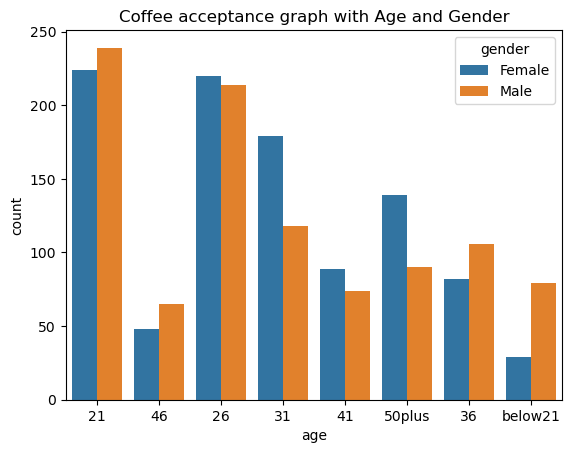

In [228]:
##### lets check acceptance with age, maritalStatus , gender, weather, temperature, passanger

## gender, age
coffee_coupon_acceptance = cofeehouse_data[cofeehouse_data['Y']==1]

sns.countplot(data=coffee_coupon_acceptance, x='age', hue='gender')
plt.title ('Coffee acceptance graph with Age and Gender')
plt.show()

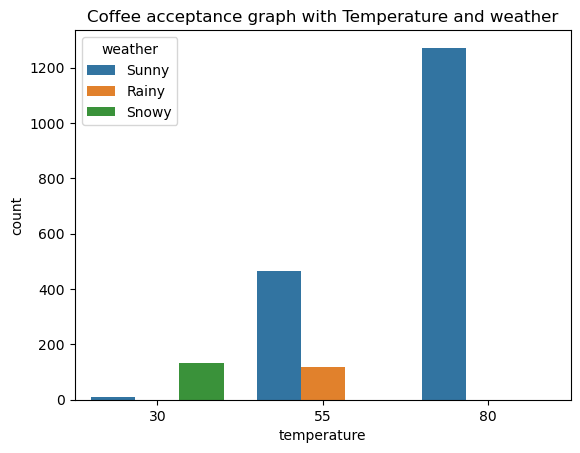

In [223]:
sns.countplot(data=coffee_coupon_acceptance, x='temperature', hue='weather')
plt.title ('Coffee acceptance graph with Temperature and weather')
plt.show()

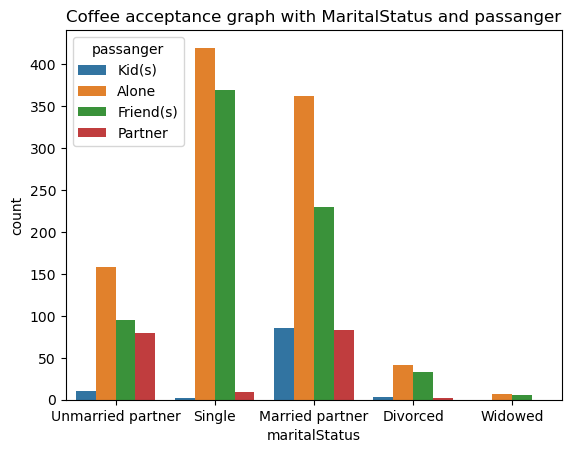

In [222]:
sns.countplot(data=coffee_coupon_acceptance, x='maritalStatus', hue='passanger')
plt.title ('Coffee acceptance graph with MaritalStatus and passanger')
plt.show()

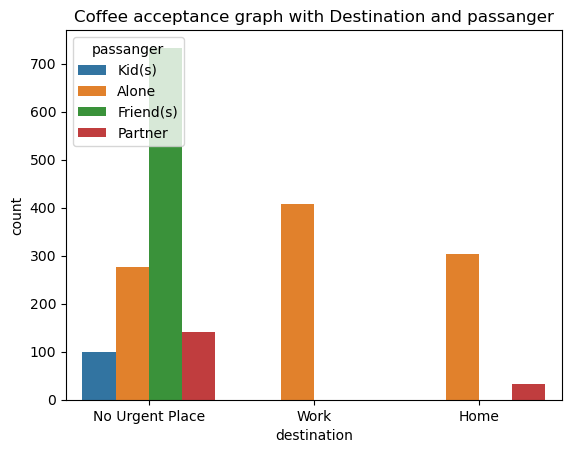

In [225]:
sns.countplot(data=coffee_coupon_acceptance, x='destination', hue='passanger')
plt.title ('Coffee acceptance graph with Destination and passanger')
plt.show()

In [ ]:
Observation for Coffee House coupons:-
    1. Highest accepected coupons with 3996 acceptance
    2. Coffee is more popular with drivers at the age of 21 yrs & 26 yrs. From 26yrs onwards, Female dominance is 
    more in coupon acceptance compared to male
    3. Sunny weather along with higher temperature triggers more acceptance
    4. Maritial status single has more inclination towards coffee coupons specially when they are alone.
    5. Company does matter as driving with friends show more coupon acceptance.